# Stage and launch checkpointed TPU jobs

Runnable locally on CPU or on a Cloud TPU VM.

- Stage the TPU launcher (`resources/tpu-gcp/launch.py`) to a Cloud TPU VM with `gcloud compute tpus tpu-vm scp`.
- Separate XLA compile warmup time from steady-state step time in structured `events.jsonl` logs.
- Write atomic checkpoints using `temp` + `os.fsync` + `os.replace` so preemption never corrupts the latest checkpoint.
- Interrupt, resume from an atomic checkpoint, and verify zero drift against an uninterrupted control run.

Once a Cloud TPU VM is running, typing ad-hoc interactive commands in an SSH shell is fragile: if the connection drops or a Spot TPU is preempted, you lose progress and cannot tell compilation time from step time. You need a repeatable way to stage code, launch TPU jobs, log structured JSONL events, and checkpoint atomically.

## The idea

A TPU job launcher enforces four contracts: (1) validate `JAX_PLATFORMS` and device discovery before training, (2) run and synchronize one warmup step so XLA compilation is recorded separately from steady updates, (3) write atomic checkpoints (`temp` + `fsync` + `os.replace`) so `--resume` continues from the exact step, parameter, optimizer, and PRNG state, and (4) copy `events.jsonl` and checkpoints back via `gcloud compute tpus tpu-vm scp`.

## Why launching a TPU experiment is different from running a notebook cell

When you launch a JAX script on a TPU VM, the first call to a `@jax.jit` step traces Python and compiles an XLA HLO program for the attached TPU chips. If you time step $1$ together with steps $2\dots N$, your step-time measurement is dominated by XLA compilation rather than TPU execution.

A production-grade TPU launcher runs one synchronized warmup call before the training loop and logs `compile_warmup_s` in a dedicated `warmup` event. Subsequent `step` events measure synchronized steady-state updates (`jax.block_until_ready`).

Whenever a checkpoint step arrives, writing directly to `checkpoint-latest.json` risks leaving a half-written file if a Spot TPU VM is preempted mid-write. Writing to a temporary sibling file (`checkpoint-latest.json.tmp`), flushing with `os.fsync`, and atomically renaming with `os.replace` guarantees that the checkpoint on disk is always complete.

$$
T_{\text{step}} = \frac{T_{\text{total}}(S) - T_{\text{compile}}(1)}{S - 1}
$$

### Checkpointed TPU job launcher lifecycle from warmup to zero-drift resume

**Predict:** Why must the warmup compilation step run before the timed step loop without overwriting the restored checkpoint state?

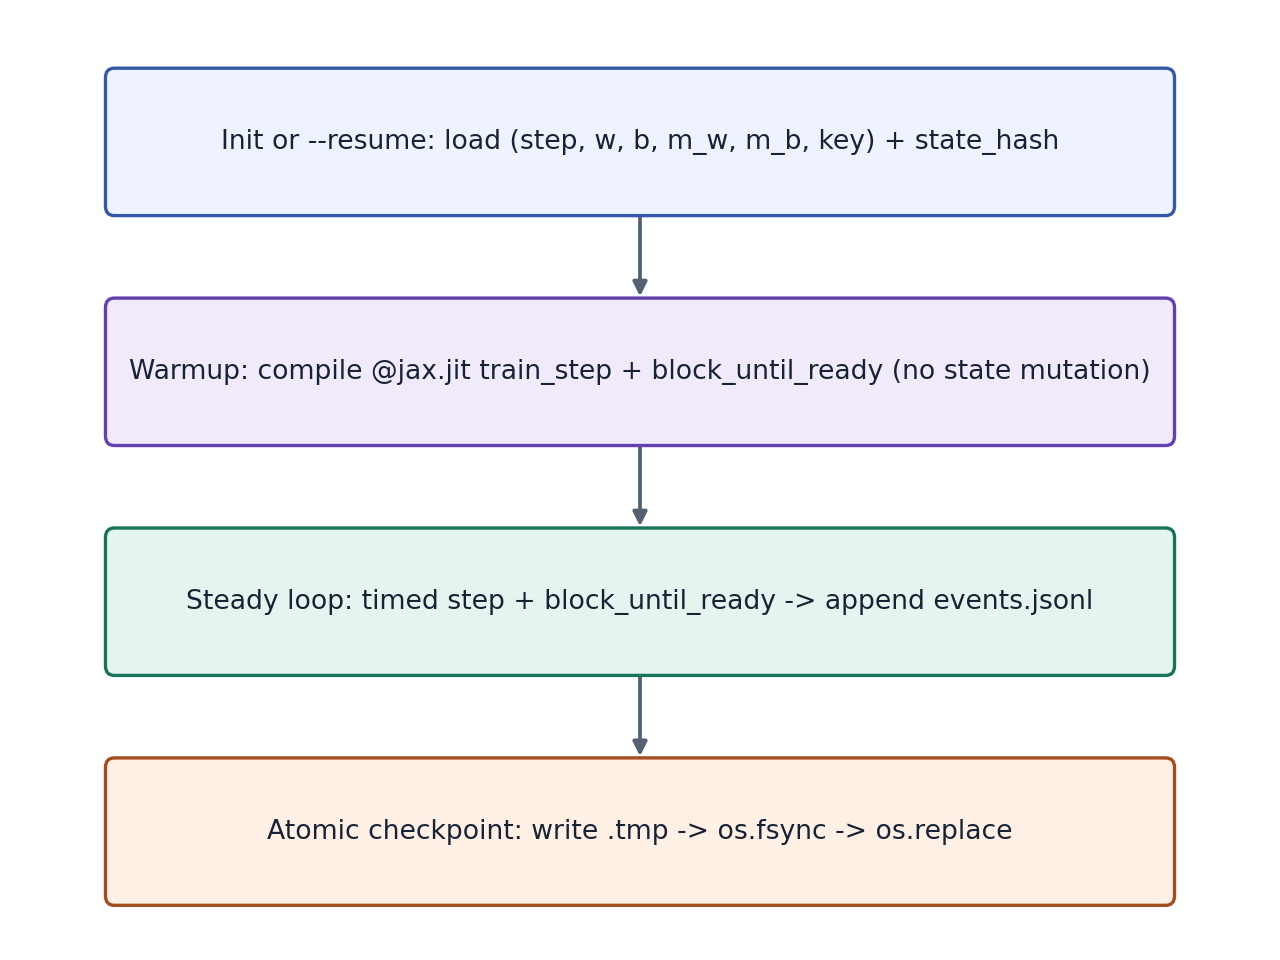

*Architecture and dataflow mechanism diagram.*

Read top to bottom: the launcher loads either the initial state or `checkpoint-latest.json`, runs one synchronized `@jax.jit` warmup call to compile XLA HLO without mutating state, executes timed steady-state steps while appending to `events.jsonl`, and writes `checkpoint-latest.json` atomically via `.tmp` + `fsync` + `os.replace`.

### Pause and reason

Why does restoring model weights alone after a Spot TPU preemption cause the resumed training curve to diverge from an uninterrupted run?

<details><summary>Compare your reasoning</summary>

Without restoring the optimizer momentum/variance buffers (`m_w`, `m_b`) and the PRNG key (`key`) alongside the step counter and weights, the next update uses zeroed momentum and a repeated or mismatched random batch.

</details>

## 1. Stage the launcher and run a checkpoint-resumed TPU experiment

Use `gcloud compute tpus tpu-vm scp` to copy `resources/tpu-gcp/launch.py` to `~/jax-tpu-lab/` on the TPU VM. Then run `launch.py --platform tpu` over SSH: first run $4$ steps and save a checkpoint at step $4$; resume to step $8$ with `--resume`; and compare the final parameter checksum against an uninterrupted $8$-step control job.

**Stage launch.py and verify checkpoint resume on the Cloud TPU VM**

```bash
# Stage launch.py and verify checkpoint resume on the Cloud TPU VM
gcloud compute tpus tpu-vm scp resources/tpu-gcp/launch.py "$TPU_NAME":~/jax-tpu-lab/ --zone="$ZONE"

gcloud compute tpus tpu-vm ssh "$TPU_NAME" --zone="$ZONE" --command="
  set -euo pipefail
  source ~/jax-tpu-lab/.venv/bin/activate
  python ~/jax-tpu-lab/launch.py --platform tpu --run-dir ~/jax-tpu-lab/run-resumed --steps 4 --save-every 2
  python ~/jax-tpu-lab/launch.py --platform tpu --run-dir ~/jax-tpu-lab/run-resumed --steps 8 --save-every 2 --resume
  python ~/jax-tpu-lab/launch.py --platform tpu --run-dir ~/jax-tpu-lab/run-control --steps 8 --save-every 2
"
```

**Expected:** Both runs emit started, warmup, step, checkpoint, and completed JSONL events with backend: tpu, and their step-8 state hashes match.

## Define deterministic hashing and atomic checkpoint writes

Create main.py with digest_obj and atomic_write_json so interrupted writes never corrupt the latest checkpoint.

In [1]:
# Step 1 — Define deterministic hashing and atomic checkpoint writes: Writing to a temporary sibling file, flushing with fsync, and...
# Import hashlib for this computation.
import hashlib
import json
import os
from pathlib import Path
import tempfile
import time
import jax
import jax.numpy as jnp
import numpy as np


# Function `digest_obj(value)` implementing this stage's computation:
def digest_obj(value):
    # Return `hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':')).encode()).hexdigest()[:16]` to the caller.
    return hashlib.sha256(
        json.dumps(value, sort_keys=True, separators=(",", ":")).encode()
    ).hexdigest()[:16]


# Function `atomic_write_json(path, payload)` implementing this stage's computation:
def atomic_write_json(path, payload):
    # Read or serialize artifact data on disk (`path`).
    path = Path(path)
    # Run `path.parent.mkdir` to perform the next check or state transition.
    path.parent.mkdir(parents=True, exist_ok=True)
    # Run `path.with_suffix` to compute `tmp`.
    tmp = path.with_suffix(path.suffix + ".tmp")
    # Enter managed runtime/context scope for this block:
    with tmp.open("w", encoding="utf-8") as f:
        # Run `json.dump` to perform the next check or state transition.
        json.dump(payload, f, sort_keys=True)
        # Run `f.flush` to perform the next check or state transition.
        f.flush()
        # Run `os.fsync` to perform the next check or state transition.
        os.fsync(f.fileno())
    # Run `os.replace` to perform the next check or state transition.
    os.replace(tmp, path)

Writing to a temporary sibling file, flushing with fsync, and calling os.replace guarantees that checkpoint-latest.json is always complete.

## Implement the TPU-ready job runner with warmup separation and resume

Append run_tpu_ready_job to main.py.

In [2]:
# Step 2 — Implement the TPU-ready job runner with warmup separation and resume: Warmup compiles the JIT function without mutating w, b, m_w, m_b,...
# Define `run_tpu_ready_job(run_dir, steps, save_every, resume...)` to evaluate the objective and its automatic derivatives:
def run_tpu_ready_job(run_dir, steps=6, save_every=2, resume=False, seed=0, lr=0.05):
    # Read or serialize artifact data on disk (`run_dir`).
    run_dir = Path(run_dir)
    # Run `run_dir.mkdir` to perform the next check or state transition.
    run_dir.mkdir(parents=True, exist_ok=True)
    # Compute `events_path` from `run_dir / "events.jsonl"`
    events_path = run_dir / "events.jsonl"
    # Compute `ckpt_path` from `run_dir / "checkpoint-latest.json"`
    ckpt_path = run_dir / "checkpoint-latest.json"

    # Function `emit(event)` implementing this stage's computation:
    def emit(event, **fields):
        # Check which hardware backend (`cpu`, `gpu`, or `tpu`) JAX selected for `record`.
        record = {"event": event, "backend": jax.default_backend(), "devices": jax.device_count(), **fields}
        # Enter managed runtime/context scope for this block:
        with events_path.open("a", encoding="utf-8") as f:
            # Compute `f.write(json.dumps(record, sort_keys` as `True) + "\n")`.
            f.write(json.dumps(record, sort_keys=True) + "\n")
        # Return `record` to the caller.
        return record

    # Generate a uniform grid of points in `x`.
    x = jnp.linspace(-1.0, 1.0, 64, dtype=jnp.float32).reshape(64, 1)
    # Compute `target_y` from `3.0 * x - 0.5`
    target_y = 3.0 * x - 0.5

    # Branch on condition `resume and ckpt_path.exists()`:
    if resume and ckpt_path.exists():
        saved = json.loads(ckpt_path.read_text(encoding="utf-8"))
        step = int(saved["step"])
        w = jnp.array(saved["w"], dtype=jnp.float32)
        b = jnp.array(saved["b"], dtype=jnp.float32)
        m_w = jnp.array(saved["m_w"], dtype=jnp.float32)
        m_b = jnp.array(saved["m_b"], dtype=jnp.float32)
        key = jnp.array(saved["key"], dtype=jnp.uint32)
        emit("restored", step=step, state_hash=saved["state_hash"])
    else:
        step = 0
        w = jnp.zeros((1, 1), dtype=jnp.float32)
        b = jnp.zeros((1,), dtype=jnp.float32)
        m_w = jnp.zeros_like(w)
        m_b = jnp.zeros_like(b)
        key = jax.random.PRNGKey(seed)
        emit("started", step=step)

    @jax.jit
    # Function `train_step(w, b, m_w, m_b, ...)` implementing this stage's computation:
    def train_step(w, b, m_w, m_b, key):
        # Split the PRNG key deterministically into independent subkeys (`(key, subkey)`).
        key, subkey = jax.random.split(key)
        # Draw pseudorandom samples for `idx` using the explicit RNG state.
        idx = jax.random.choice(subkey, 64, shape=(16,), replace=False)
        # Compute `xb, yb` from `x[idx], target_y[idx]`
        xb, yb = x[idx], target_y[idx]

        # Function `loss_fn(w_in, b_in)` implementing this stage's computation:
        def loss_fn(w_in, b_in):
            # Perform matrix contraction / projection to compute `pred`.
            pred = xb @ w_in + b_in
            # Return `jnp.mean((pred - yb) ** 2)` to the caller.
            return jnp.mean((pred - yb) ** 2)

        # Evaluate both scalar loss and parameter gradients in one pass (`(loss, (gw, gb))`).
        loss, (gw, gb) = jax.value_and_grad(loss_fn, argnums=(0, 1))(w, b)
        # Compute `m_w` from `0.8 * m_w + gw`
        m_w = 0.8 * m_w + gw
        # Compute `m_b` from `0.8 * m_b + gb`
        m_b = 0.8 * m_b + gb
        # Compute `w` from `w - lr * m_w`
        w = w - lr * m_w
        # Compute `b` from `b - lr * m_b`
        b = b - lr * m_b
        # Return `(w, b, m_w, m_b, key, loss)` to the caller.
        return w, b, m_w, m_b, key, loss

    # Record execution timing or profiler trace in `t0`.
    t0 = time.perf_counter()
    # Run `train_step` to compute `warm`.
    warm = train_step(w, b, m_w, m_b, key)
    # Synchronize host execution until asynchronous device computation completes.
    jax.block_until_ready(warm)
    # Record execution timing or profiler trace in `warmup_ms`.
    warmup_ms = (time.perf_counter() - t0) * 1000.0
    # Run `emit` to perform the next check or state transition.
    emit("warmup", warmup_ms=warmup_ms, step=step)

    # Compute `step_losses` from `[]`
    step_losses = []
    # Compute `step_times_ms` from `[]`
    step_times_ms = []
    while step < steps:
        t_step = time.perf_counter()
        w, b, m_w, m_b, key, loss = train_step(w, b, m_w, m_b, key)
        jax.block_until_ready((w, b, m_w, m_b, key, loss))
        elapsed_ms = (time.perf_counter() - t_step) * 1000.0
        step += 1
        state_payload = {
            "step": step,
            "w": np.asarray(w).tolist(),
            "b": np.asarray(b).tolist(),
            "m_w": np.asarray(m_w).tolist(),
            "m_b": np.asarray(m_b).tolist(),
            "key": np.asarray(key).tolist(),
        }
        state_payload["state_hash"] = digest_obj(state_payload)
        step_losses.append(float(loss))
        step_times_ms.append(float(elapsed_ms))
        emit("step", step=step, loss=float(loss), step_ms=elapsed_ms, state_hash=state_payload["state_hash"])
        if step % save_every == 0 or step == steps:
            atomic_write_json(ckpt_path, state_payload)
            emit("checkpoint", step=step, state_hash=state_payload["state_hash"])

    # Run `emit` to perform the next check or state transition.
    emit("completed", step=step, state_hash=state_payload["state_hash"])
    # Return `{'final_step': step, 'state_hash': state_payload['state_hash'], 'w': float(np.asarray(w).squeeze()), 'b': float(np.asarray(b).squeeze()), 'warmup_ms': warmup_ms, 'step_losses': step_losses, 'step_times_ms': step_times_ms}` to the caller.
    return {
        "final_step": step,
        "state_hash": state_payload["state_hash"],
        "w": float(np.asarray(w).squeeze()),
        "b": float(np.asarray(b).squeeze()),
        "warmup_ms": warmup_ms,
        "step_losses": step_losses,
        "step_times_ms": step_times_ms,
    }

Warmup compiles the JIT function without mutating w, b, m_w, m_b, or key, so step 1 starts from the exact initial or restored state.

## Compare a checkpoint-resumed run against an uninterrupted control run

Append the 3-step + 3-step resumed run and 6-step uninterrupted control comparison to main.py.

In [3]:
# Step 3 — Compare a checkpoint-resumed run against an uninterrupted control run: Because parameters, momentum buffers, and PRNG keys are all...
# Create an isolated temporary directory to run and inspect artifacts safely:
with tempfile.TemporaryDirectory(prefix="tpu-launch-") as tmp:
    # Read or serialize artifact data on disk (`root`).
    root = Path(tmp)
    # Run `run_tpu_ready_job` to compute `part1`.
    part1 = run_tpu_ready_job(root / "resumed", steps=3, save_every=3, resume=False)
    # Run `run_tpu_ready_job` to compute `part2`.
    part2 = run_tpu_ready_job(root / "resumed", steps=6, save_every=3, resume=True)
    # Run `run_tpu_ready_job` to compute `control`.
    control = run_tpu_ready_job(root / "control", steps=6, save_every=3, resume=False)
    # Compute `resumed_losses` from `part1["step_losses"] + part2["step_losses"]`
    resumed_losses = part1["step_losses"] + part2["step_losses"]

# Assert invariant `part2["state_hash"] == control["state_hash"]` holds
assert part2["state_hash"] == control["state_hash"]
# Assert that `np.allclose(resumed_losses, control["step_losses"])`.
assert np.allclose(resumed_losses, control["step_losses"])
# Print the observed values to compare against the expected result.
print("Resumed state_hash matches uninterrupted control:", part2["state_hash"])
# Print diagnostic summary of the computed outputs.
print("Losses across 6 steps:", [round(v, 5) for v in control["step_losses"]])

Resumed state_hash matches uninterrupted control: 62b9a0a939c380dc
Losses across 6 steps: [3.6712, 3.78913, 1.91372, 2.09553, 1.81174, 1.16636]


Because parameters, momentum buffers, and PRNG keys are all restored, the resumed trajectory matches the uninterrupted trajectory bit-for-bit.

## Run the example

In [4]:
# Step 1 — Define deterministic hashing and atomic checkpoint writes: Writing to a temporary sibling file, flushing with fsync, and...
# Import hashlib for this computation.
import hashlib
import json
import os
from pathlib import Path
import tempfile
import time
import jax
import jax.numpy as jnp
import numpy as np


# Function `digest_obj(value)` implementing this stage's computation:
def digest_obj(value):
    # Return `hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':')).encode()).hexdigest()[:16]` to the caller.
    return hashlib.sha256(
        json.dumps(value, sort_keys=True, separators=(",", ":")).encode()
    ).hexdigest()[:16]


# Function `atomic_write_json(path, payload)` implementing this stage's computation:
def atomic_write_json(path, payload):
    # Read or serialize artifact data on disk (`path`).
    path = Path(path)
    # Run `path.parent.mkdir` to perform the next check or state transition.
    path.parent.mkdir(parents=True, exist_ok=True)
    # Run `path.with_suffix` to compute `tmp`.
    tmp = path.with_suffix(path.suffix + ".tmp")
    # Enter managed runtime/context scope for this block:
    with tmp.open("w", encoding="utf-8") as f:
        # Run `json.dump` to perform the next check or state transition.
        json.dump(payload, f, sort_keys=True)
        # Run `f.flush` to perform the next check or state transition.
        f.flush()
        # Run `os.fsync` to perform the next check or state transition.
        os.fsync(f.fileno())
    # Run `os.replace` to perform the next check or state transition.
    os.replace(tmp, path)


# Step 2 — Implement the TPU-ready job runner with warmup separation and resume: Warmup compiles the JIT function without mutating w, b, m_w, m_b,...
# Define `run_tpu_ready_job(run_dir, steps, save_every, resume...)` to evaluate the objective and its automatic derivatives:
def run_tpu_ready_job(run_dir, steps=6, save_every=2, resume=False, seed=0, lr=0.05):
    # Read or serialize artifact data on disk (`run_dir`).
    run_dir = Path(run_dir)
    # Run `run_dir.mkdir` to perform the next check or state transition.
    run_dir.mkdir(parents=True, exist_ok=True)
    # Compute `events_path` from `run_dir / "events.jsonl"`
    events_path = run_dir / "events.jsonl"
    # Compute `ckpt_path` from `run_dir / "checkpoint-latest.json"`
    ckpt_path = run_dir / "checkpoint-latest.json"

    # Function `emit(event)` implementing this stage's computation:
    def emit(event, **fields):
        # Check which hardware backend (`cpu`, `gpu`, or `tpu`) JAX selected for `record`.
        record = {"event": event, "backend": jax.default_backend(), "devices": jax.device_count(), **fields}
        # Enter managed runtime/context scope for this block:
        with events_path.open("a", encoding="utf-8") as f:
            # Compute `f.write(json.dumps(record, sort_keys` as `True) + "\n")`.
            f.write(json.dumps(record, sort_keys=True) + "\n")
        # Return `record` to the caller.
        return record

    # Generate a uniform grid of points in `x`.
    x = jnp.linspace(-1.0, 1.0, 64, dtype=jnp.float32).reshape(64, 1)
    # Compute `target_y` from `3.0 * x - 0.5`
    target_y = 3.0 * x - 0.5

    # Branch on condition `resume and ckpt_path.exists()`:
    if resume and ckpt_path.exists():
        saved = json.loads(ckpt_path.read_text(encoding="utf-8"))
        step = int(saved["step"])
        w = jnp.array(saved["w"], dtype=jnp.float32)
        b = jnp.array(saved["b"], dtype=jnp.float32)
        m_w = jnp.array(saved["m_w"], dtype=jnp.float32)
        m_b = jnp.array(saved["m_b"], dtype=jnp.float32)
        key = jnp.array(saved["key"], dtype=jnp.uint32)
        emit("restored", step=step, state_hash=saved["state_hash"])
    else:
        step = 0
        w = jnp.zeros((1, 1), dtype=jnp.float32)
        b = jnp.zeros((1,), dtype=jnp.float32)
        m_w = jnp.zeros_like(w)
        m_b = jnp.zeros_like(b)
        key = jax.random.PRNGKey(seed)
        emit("started", step=step)

    @jax.jit
    # Function `train_step(w, b, m_w, m_b, ...)` implementing this stage's computation:
    def train_step(w, b, m_w, m_b, key):
        # Split the PRNG key deterministically into independent subkeys (`(key, subkey)`).
        key, subkey = jax.random.split(key)
        # Draw pseudorandom samples for `idx` using the explicit RNG state.
        idx = jax.random.choice(subkey, 64, shape=(16,), replace=False)
        # Compute `xb, yb` from `x[idx], target_y[idx]`
        xb, yb = x[idx], target_y[idx]

        # Function `loss_fn(w_in, b_in)` implementing this stage's computation:
        def loss_fn(w_in, b_in):
            # Perform matrix contraction / projection to compute `pred`.
            pred = xb @ w_in + b_in
            # Return `jnp.mean((pred - yb) ** 2)` to the caller.
            return jnp.mean((pred - yb) ** 2)

        # Evaluate both scalar loss and parameter gradients in one pass (`(loss, (gw, gb))`).
        loss, (gw, gb) = jax.value_and_grad(loss_fn, argnums=(0, 1))(w, b)
        # Compute `m_w` from `0.8 * m_w + gw`
        m_w = 0.8 * m_w + gw
        # Compute `m_b` from `0.8 * m_b + gb`
        m_b = 0.8 * m_b + gb
        # Compute `w` from `w - lr * m_w`
        w = w - lr * m_w
        # Compute `b` from `b - lr * m_b`
        b = b - lr * m_b
        # Return `(w, b, m_w, m_b, key, loss)` to the caller.
        return w, b, m_w, m_b, key, loss

    # Record execution timing or profiler trace in `t0`.
    t0 = time.perf_counter()
    # Run `train_step` to compute `warm`.
    warm = train_step(w, b, m_w, m_b, key)
    # Synchronize host execution until asynchronous device computation completes.
    jax.block_until_ready(warm)
    # Record execution timing or profiler trace in `warmup_ms`.
    warmup_ms = (time.perf_counter() - t0) * 1000.0
    # Run `emit` to perform the next check or state transition.
    emit("warmup", warmup_ms=warmup_ms, step=step)

    # Compute `step_losses` from `[]`
    step_losses = []
    # Compute `step_times_ms` from `[]`
    step_times_ms = []
    while step < steps:
        t_step = time.perf_counter()
        w, b, m_w, m_b, key, loss = train_step(w, b, m_w, m_b, key)
        jax.block_until_ready((w, b, m_w, m_b, key, loss))
        elapsed_ms = (time.perf_counter() - t_step) * 1000.0
        step += 1
        state_payload = {
            "step": step,
            "w": np.asarray(w).tolist(),
            "b": np.asarray(b).tolist(),
            "m_w": np.asarray(m_w).tolist(),
            "m_b": np.asarray(m_b).tolist(),
            "key": np.asarray(key).tolist(),
        }
        state_payload["state_hash"] = digest_obj(state_payload)
        step_losses.append(float(loss))
        step_times_ms.append(float(elapsed_ms))
        emit("step", step=step, loss=float(loss), step_ms=elapsed_ms, state_hash=state_payload["state_hash"])
        if step % save_every == 0 or step == steps:
            atomic_write_json(ckpt_path, state_payload)
            emit("checkpoint", step=step, state_hash=state_payload["state_hash"])

    # Run `emit` to perform the next check or state transition.
    emit("completed", step=step, state_hash=state_payload["state_hash"])
    # Return `{'final_step': step, 'state_hash': state_payload['state_hash'], 'w': float(np.asarray(w).squeeze()), 'b': float(np.asarray(b).squeeze()), 'warmup_ms': warmup_ms, 'step_losses': step_losses, 'step_times_ms': step_times_ms}` to the caller.
    return {
        "final_step": step,
        "state_hash": state_payload["state_hash"],
        "w": float(np.asarray(w).squeeze()),
        "b": float(np.asarray(b).squeeze()),
        "warmup_ms": warmup_ms,
        "step_losses": step_losses,
        "step_times_ms": step_times_ms,
    }


# Step 3 — Compare a checkpoint-resumed run against an uninterrupted control run: Because parameters, momentum buffers, and PRNG keys are all...
# Create an isolated temporary directory to run and inspect artifacts safely:
with tempfile.TemporaryDirectory(prefix="tpu-launch-") as tmp:
    # Read or serialize artifact data on disk (`root`).
    root = Path(tmp)
    # Run `run_tpu_ready_job` to compute `part1`.
    part1 = run_tpu_ready_job(root / "resumed", steps=3, save_every=3, resume=False)
    # Run `run_tpu_ready_job` to compute `part2`.
    part2 = run_tpu_ready_job(root / "resumed", steps=6, save_every=3, resume=True)
    # Run `run_tpu_ready_job` to compute `control`.
    control = run_tpu_ready_job(root / "control", steps=6, save_every=3, resume=False)
    # Compute `resumed_losses` from `part1["step_losses"] + part2["step_losses"]`
    resumed_losses = part1["step_losses"] + part2["step_losses"]

# Assert invariant `part2["state_hash"] == control["state_hash"]` holds
assert part2["state_hash"] == control["state_hash"]
# Assert that `np.allclose(resumed_losses, control["step_losses"])`.
assert np.allclose(resumed_losses, control["step_losses"])
# Print the observed values to compare against the expected result.
print("Resumed state_hash matches uninterrupted control:", part2["state_hash"])
# Print diagnostic summary of the computed outputs.
print("Losses across 6 steps:", [round(v, 5) for v in control["step_losses"]])

Resumed state_hash matches uninterrupted control: 62b9a0a939c380dc
Losses across 6 steps: [3.6712, 3.78913, 1.91372, 2.09553, 1.81174, 1.16636]


Expected: Prints the matching 16-character state_hash for the resumed and control runs and the monotonically decreasing 6-step loss trajectory.

## Interrupted-and-resumed trajectory vs uninterrupted 6-step control run

Predict: Does stopping after step 3 and resuming in a fresh call change the loss trajectory on steps 4 through 6?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Interrupted-and-resumed trajectory vs uninterrupted 6-step control run
# Construct dictionary `visual_data` with the structured fields for this stage.
visual_data = {
    'kind': 'line',
    'x': [1, 2, 3, 4, 5, 6],
    'xlabel': 'training step',
    'ylabel': 'minibatch mean-squared loss',
    'boundaries': [3],
    'series': [
        {'label': 'uninterrupted 6-step control', 'y': [float(v) for v in control['step_losses']]},
        {'label': 'stopped at step 3 + resumed (steps 4-6)', 'y': [float(v) for v in resumed_losses]},
    ],
}

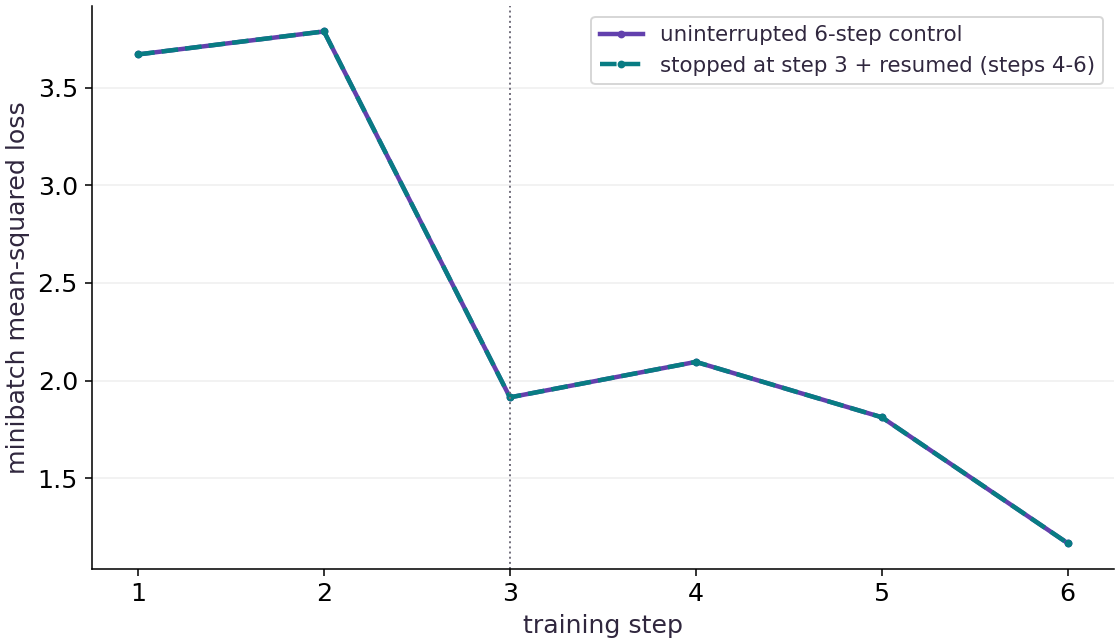

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis shows training steps 1 through 6, with a vertical dotted boundary at step 3 where the first run stopped and wrote its checkpoint. The solid line is the uninterrupted 6-step control run; the dashed line is the run that stopped at step 3 and resumed for steps 4–6.

### Connect it to the computation

Because the checkpoint at step 3 saved `(w, b, m_w, m_b, key)` atomically and the warmup call did not consume the restored state, the two loss trajectories lie directly on top of each other (`max_abs_diff == 0`).

## Compare JIT warmup latency against steady-state step latency

Predict: How does the warmup call duration compare to the median steady-state step duration?

In [7]:
# Experiment — Compare JIT warmup latency against steady-state step latency: Logging warmup separately in events.jsonl prevents compilation...
median_step_ms = float(np.median(control["step_times_ms"]))
# Print the observed values to compare against the expected result.
print("Warmup ms:", round(control["warmup_ms"], 3), "Median steady step ms:", round(median_step_ms, 4))
# Assert invariant `control["warmup_ms"] > median_step_ms` holds
assert control["warmup_ms"] > median_step_ms

Warmup ms: 95.593 Median steady step ms: 0.0413


Expected: Warmup takes significantly longer than a steady-state compiled step because it includes tracing and XLA compilation.

Logging warmup separately in events.jsonl prevents compilation overhead from distorting per-step throughput numbers on CPU or TPU.

## Verify what breaks if momentum state is omitted on resume

Predict: If a resumed job resets momentum buffers m_w and m_b to zero at step 3, will step 4 match the uninterrupted run?

In [8]:
# Experiment — Verify what breaks if momentum state is omitted on resume: Restoring model weights alone is not a valid checkpoint resume;...
# Create an isolated temporary directory to run and inspect artifacts safely:
with tempfile.TemporaryDirectory(prefix="tpu-bad-resume-") as tmp:
    # Read or serialize artifact data on disk (`bad_dir`).
    bad_dir = Path(tmp) / "bad"
    # Run `run_tpu_ready_job` to perform the next check or state transition.
    run_tpu_ready_job(bad_dir, steps=3, save_every=3, resume=False)
    # Read or serialize artifact data on disk (`ckpt`).
    ckpt = json.loads((bad_dir / "checkpoint-latest.json").read_text(encoding="utf-8"))
    # Compute `ckpt["m_w"]` from `[[0.0]]`
    ckpt["m_w"] = [[0.0]]
    # Compute `ckpt["m_b"]` from `[0.0]`
    ckpt["m_b"] = [0.0]
    # Compute `(bad_dir / "checkpoint-latest.json").write_text(json.dumps(ckpt), encoding` as `"utf-8")`.
    (bad_dir / "checkpoint-latest.json").write_text(json.dumps(ckpt), encoding="utf-8")
    # Run `run_tpu_ready_job` to compute `bad_part2`.
    bad_part2 = run_tpu_ready_job(bad_dir, steps=6, save_every=3, resume=True)
# Print the observed values to compare against the expected result.
print("Drifted state_hash vs control:", bad_part2["state_hash"], control["state_hash"])
# Assert invariant `bad_part2["state_hash"] != control["state_hash"]` holds
assert bad_part2["state_hash"] != control["state_hash"]

Drifted state_hash vs control: 98b637bef786a354 62b9a0a939c380dc


Expected: Resetting momentum at step 3 produces a different step-6 state_hash and loss trajectory.

Restoring model weights alone is not a valid checkpoint resume; optimizer state and PRNG keys must be restored together.

## Your exercise

Run `run_tpu_ready_job` for $4$ steps (`save_every=2`), resume to $8$ steps, and verify that the final `state_hash` at step $8$ equals an uninterrupted $8$-step run.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `steps(...)` — Call `steps` with your updated parameters or inputs from this lesson's workspace.
- `tempfile.TemporaryDirectory(...)` — Call `tempfile.TemporaryDirectory` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Create an isolated temporary directory to run and inspect artifacts safely:
2. Read or serialize artifact data on disk (`ex_root`).
3. Run `run_tpu_ready_job` to compute `r1`.
4. Run `run_tpu_ready_job` to compute `r2`.
5. Run `run_tpu_ready_job` to compute `ctrl8`.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Run run_tpu_ready_job for 4 steps (save_every=2), resume to 8 steps,...
# Create an isolated temporary directory to run and inspect artifacts safely:
with tempfile.TemporaryDirectory(prefix="tpu-ex-") as tmp:
    # Read or serialize artifact data on disk (`ex_root`).
    ex_root = Path(...)  # TODO: compute ex_root
    # Run `run_tpu_ready_job` to compute `r1`.
    r1 = run_tpu_ready_job(...)  # TODO: compute r1
    # Run `run_tpu_ready_job` to compute `r2`.
    r2 = run_tpu_ready_job(...)  # TODO: compute r2
    # Run `run_tpu_ready_job` to compute `ctrl8`.
    ctrl8 = run_tpu_ready_job(...)  # TODO: compute ctrl8
# Print the observed values to compare against the expected result.
print("Step 8 resumed vs control hash:", r2["state_hash"], ctrl8["state_hash"])
# Assert that `r2["state_hash"] == ctrl8["state_hash"] and len(r1["step_losses"] + r2["step_losses"]) == 8`.
assert r2["state_hash"]  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Run run_tpu_ready_job for 4 steps (save_every=2), resume to 8 steps,...
# Create an isolated temporary directory to run and inspect artifacts safely:
# with tempfile.TemporaryDirectory(prefix="tpu-ex-") as tmp:
    # Read or serialize artifact data on disk (`ex_root`).
#     ex_root = Path(...)  # TODO: compute ex_root
    # Run `run_tpu_ready_job` to compute `r1`.
#     r1 = run_tpu_ready_job(...)  # TODO: compute r1
    # Run `run_tpu_ready_job` to compute `r2`.
#     r2 = run_tpu_ready_job(...)  # TODO: compute r2
    # Run `run_tpu_ready_job` to compute `ctrl8`.
#     ctrl8 = run_tpu_ready_job(...)  # TODO: compute ctrl8
# Print the observed values to compare against the expected result.
# print("Step 8 resumed vs control hash:", r2["state_hash"], ctrl8["state_hash"])
# Assert that `r2["state_hash"] == ctrl8["state_hash"] and len(r1["step_losses"] + r2["step_losses"]) == 8`.
# assert r2["state_hash"]  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Run run_tpu_ready_job for 4 steps (save_every=2), resume to 8 steps,...
# Create an isolated temporary directory to run and inspect artifacts safely:
with tempfile.TemporaryDirectory(prefix="tpu-ex-") as tmp:
    # Read or serialize artifact data on disk (`ex_root`).
    ex_root = Path(tmp)
    # Run `run_tpu_ready_job` to compute `r1`.
    r1 = run_tpu_ready_job(ex_root / "resumed", steps=4, save_every=2, resume=False)
    # Run `run_tpu_ready_job` to compute `r2`.
    r2 = run_tpu_ready_job(ex_root / "resumed", steps=8, save_every=2, resume=True)
    # Run `run_tpu_ready_job` to compute `ctrl8`.
    ctrl8 = run_tpu_ready_job(ex_root / "control", steps=8, save_every=2, resume=False)
# Print the observed values to compare against the expected result.
print("Step 8 resumed vs control hash:", r2["state_hash"], ctrl8["state_hash"])
# Assert that `r2["state_hash"] == ctrl8["state_hash"] and len(r1["step_losses"] + r2["step_losses"]) == 8`.
assert r2["state_hash"] == ctrl8["state_hash"] and len(r1["step_losses"] + r2["step_losses"]) == 8

Step 8 resumed vs control hash: c2f49383b86e426e c2f49383b86e426e


## Inspect the JSONL event sequence from a resumed run · Foundations

Run a $2$-step job followed by a `--resume` to step $4$ and list the ordered `event` names recorded in `events.jsonl`.

Hint: Read `events.jsonl` line by line with `json.loads`.

### How to write: Inspect the JSONL event sequence from a resumed run — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `run(...)` — Call `run` with your updated parameters or inputs from this lesson's workspace.
- `tempfile.TemporaryDirectory(...)` — Call `tempfile.TemporaryDirectory` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Inspect the JSONL event sequence from a resumed run (Foundations): The single append-only events.jsonl log captures both the...
2. Create an isolated temporary directory to run and inspect artifacts safely:
3. Read or serialize artifact data on disk (`ev_dir`).
4. Run `run_tpu_ready_job` to perform the next check or state transition.
5. Run `run_tpu_ready_job` to perform the next check or state transition.

**Starter code scaffold (fill in the TODOs):**

```python
# Inspect the JSONL event sequence from a resumed run (Foundations): The single append-only events.jsonl log captures both the...
# Create an isolated temporary directory to run and inspect artifacts safely:
with tempfile.TemporaryDirectory(prefix="tpu-events-") as tmp:
    # Read or serialize artifact data on disk (`ev_dir`).
    ev_dir = Path(...)  # TODO: compute ev_dir
    # Run `run_tpu_ready_job` to perform the next check or state transition.
    run_tpu_ready_job(ev_dir, steps = ...  # TODO: compute run_tpu_ready_job(ev_dir, steps
    # Run `run_tpu_ready_job` to perform the next check or state transition.
    run_tpu_ready_job(ev_dir, steps = ...  # TODO: compute run_tpu_ready_job(ev_dir, steps
    # Read or serialize artifact data on disk (`event_names`).
    event_names = ...  # TODO: compute event_names
# Print the observed values to compare against the expected result.
print("Recorded event sequence:", event_names)
# Assert that `"started" in event_names and "restored" in event_names and event_names[-1] == "completed"`.
assert "started"  # TODO: complete assertion check
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Inspect the JSONL event sequence from a resumed run (Foundations): The single append-only events.jsonl log captures both the...
# Create an isolated temporary directory to run and inspect artifacts safely:
# with tempfile.TemporaryDirectory(prefix="tpu-events-") as tmp:
    # Read or serialize artifact data on disk (`ev_dir`).
#     ev_dir = Path(...)  # TODO: compute ev_dir
    # Run `run_tpu_ready_job` to perform the next check or state transition.
#     run_tpu_ready_job(ev_dir, steps = ...  # TODO: compute run_tpu_ready_job(ev_dir, steps
    # Run `run_tpu_ready_job` to perform the next check or state transition.
#     run_tpu_ready_job(ev_dir, steps = ...  # TODO: compute run_tpu_ready_job(ev_dir, steps
    # Read or serialize artifact data on disk (`event_names`).
#     event_names = ...  # TODO: compute event_names
# Print the observed values to compare against the expected result.
# print("Recorded event sequence:", event_names)
# Assert that `"started" in event_names and "restored" in event_names and event_names[-1] == "completed"`.
# assert "started"  # TODO: complete assertion check

## Reference reasoning

The single append-only events.jsonl log captures both the initial run (`started` -> `warmup` -> `step` -> `checkpoint` -> `completed`) and the resumed run (`restored` -> `warmup` -> `step` -> `checkpoint` -> `completed`).

In [12]:
# Inspect the JSONL event sequence from a resumed run (Foundations): The single append-only events.jsonl log captures both the...
# Create an isolated temporary directory to run and inspect artifacts safely:
with tempfile.TemporaryDirectory(prefix="tpu-events-") as tmp:
    # Read or serialize artifact data on disk (`ev_dir`).
    ev_dir = Path(tmp) / "job"
    # Run `run_tpu_ready_job` to perform the next check or state transition.
    run_tpu_ready_job(ev_dir, steps=2, save_every=2, resume=False)
    # Run `run_tpu_ready_job` to perform the next check or state transition.
    run_tpu_ready_job(ev_dir, steps=4, save_every=2, resume=True)
    # Read or serialize artifact data on disk (`event_names`).
    event_names = [json.loads(line)["event"] for line in (ev_dir / "events.jsonl").read_text().splitlines()]
# Print the observed values to compare against the expected result.
print("Recorded event sequence:", event_names)
# Assert that `"started" in event_names and "restored" in event_names and event_names[-1] == "completed"`.
assert "started" in event_names and "restored" in event_names and event_names[-1] == "completed"

Recorded event sequence: ['started', 'warmup', 'step', 'step', 'checkpoint', 'completed', 'restored', 'warmup', 'step', 'step', 'checkpoint', 'completed']


## Verify atomic checkpoint file replacement · Transfer / diagnosis

Write a small test that calls `atomic_write_json` twice on the same path and confirms that no `.tmp` file remains alongside the final JSON file.

Hint: Check `list(Path(tmp).glob('*.tmp')) == []`.

### How to write: Verify atomic checkpoint file replacement — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `replacement(...)` — Call `replacement` with your updated parameters or inputs from this lesson's workspace.
- `tempfile.TemporaryDirectory(...)` — Call `tempfile.TemporaryDirectory` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Create an isolated temporary directory to run and inspect artifacts safely:
2. Read or serialize artifact data on disk (`target`).
3. Run `atomic_write_json` to perform the next check or state transition.
4. Run `atomic_write_json` to perform the next check or state transition.
5. Read or serialize artifact data on disk (`leftovers`).

**Starter code scaffold (fill in the TODOs):**

```python
# Verify atomic checkpoint file replacement (Transfer / diagnosis): os.replace atomically swaps the flushed .tmp file into...
# Create an isolated temporary directory to run and inspect artifacts safely:
with tempfile.TemporaryDirectory(prefix="tpu-atomic-") as tmp:
    # Read or serialize artifact data on disk (`target`).
    target = Path(...)  # TODO: compute target
    # Run `atomic_write_json` to perform the next check or state transition.
    atomic_write_json(target, {"step": 2})
    # Run `atomic_write_json` to perform the next check or state transition.
    atomic_write_json(target, {"step": 4})
    # Read or serialize artifact data on disk (`leftovers`).
    leftovers = list(...)  # TODO: compute leftovers
    # Read or serialize artifact data on disk (`loaded`).
    loaded = json.loads(...)  # TODO: compute loaded
# Print the observed values to compare against the expected result.
print("Loaded step:", loaded["step"], "Leftover tmp files:", leftovers)
# Assert invariant `loaded["step"] == 4 and leftovers == []` holds
assert loaded["step"]  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Verify atomic checkpoint file replacement (Transfer / diagnosis): os.replace atomically swaps the flushed .tmp file into...
# Create an isolated temporary directory to run and inspect artifacts safely:
# with tempfile.TemporaryDirectory(prefix="tpu-atomic-") as tmp:
    # Read or serialize artifact data on disk (`target`).
#     target = Path(...)  # TODO: compute target
    # Run `atomic_write_json` to perform the next check or state transition.
#     atomic_write_json(target, {"step": 2})
    # Run `atomic_write_json` to perform the next check or state transition.
#     atomic_write_json(target, {"step": 4})
    # Read or serialize artifact data on disk (`leftovers`).
#     leftovers = list(...)  # TODO: compute leftovers
    # Read or serialize artifact data on disk (`loaded`).
#     loaded = json.loads(...)  # TODO: compute loaded
# Print the observed values to compare against the expected result.
# print("Loaded step:", loaded["step"], "Leftover tmp files:", leftovers)
# Assert invariant `loaded["step"] == 4 and leftovers == []` holds
# assert loaded["step"]  # TODO: complete assertion check

## Reference reasoning

`os.replace` atomically swaps the flushed `.tmp` file into `checkpoint-latest.json`, leaving zero partial files behind.

In [14]:
# Verify atomic checkpoint file replacement (Transfer / diagnosis): os.replace atomically swaps the flushed .tmp file into...
# Create an isolated temporary directory to run and inspect artifacts safely:
with tempfile.TemporaryDirectory(prefix="tpu-atomic-") as tmp:
    # Read or serialize artifact data on disk (`target`).
    target = Path(tmp) / "checkpoint-latest.json"
    # Run `atomic_write_json` to perform the next check or state transition.
    atomic_write_json(target, {"step": 2})
    # Run `atomic_write_json` to perform the next check or state transition.
    atomic_write_json(target, {"step": 4})
    # Read or serialize artifact data on disk (`leftovers`).
    leftovers = list(Path(tmp).glob("*.tmp"))
    # Read or serialize artifact data on disk (`loaded`).
    loaded = json.loads(target.read_text(encoding="utf-8"))
# Print the observed values to compare against the expected result.
print("Loaded step:", loaded["step"], "Leftover tmp files:", leftovers)
# Assert invariant `loaded["step"] == 4 and leftovers == []` holds
assert loaded["step"] == 4 and leftovers == []

Loaded step: 4 Leftover tmp files: []


## Checkpoint

Why does `run_tpu_ready_job` execute `train_step` once and discard its outputs before starting the timed `while step < steps` loop?

1. To mutate the parameters one extra time before step 1
2. To trigger XLA compilation and synchronize the warmup result without altering the initial or restored training state, keeping compilation latency out of steady-state step measurements
3. Because JAX cannot save checkpoints without a warmup call

## Diagnose

If a resumed TPU run diverges from an uninterrupted run, check whether optimizer moments (`m_w`, `m_b`), PRNG `key`, or dataset position were omitted from the checkpoint.

## Evidence

Keep events.jsonl (started, warmup, step, checkpoint, restored, completed), checkpoint-latest.json, and matching resumed vs control state hashes.

## Carry forward

- Always separate `@jax.jit` warmup compilation from steady-state step timing and call `jax.block_until_ready`.
- Atomic checkpoints (`temp` + `fsync` + `os.replace`) containing parameters, optimizer state, and PRNG keys allow interrupted or Spot TPU runs to resume without numerical drift.

## Primary references

- [Run JAX code on Cloud TPU VMs](https://cloud.google.com/tpu/docs/run-calculation-jax)
- [Orbax checkpointing guide](https://orbax.readthedocs.io/en/latest/)